<a href="https://colab.research.google.com/github/ouchn2580201251107/04399_Big_Data_Analytics_Mining_Tech/blob/main/04399_BigData_Ex2(Rejected).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install numpy pandas

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/04399_Big_Data_Analytics&Mining_Tech/data/breast-cancer-wisconsin.csv", header=None, encoding='utf-8')

data.columns = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape','Marginal Adhesion',
                'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin','Normal Nucleoli', 'Mitoses','Class']


print('数据量： %d' % (data.shape[0]))

print('数据属性： %d' % (data.shape[1]))

data.head()

数据量： 699
数据属性： 11


,Sample code,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [8]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=data)

https://docs.google.com/spreadsheets/d/1vyKjSZ0OF1gSd-Jq0dDwaNZg8kneEPDrL4WOztf7bCQ/edit#gid=0


In [13]:
import numpy as np

data = data.replace('?',np.nan)

print('数据量： %d' % (data.shape[0]))

print('数据属性： %d' % (data.shape[1]))

print('缺失值个数:')

for col in data.columns:
    print('属性：%s， 个数： %d' % (col,data[col].isna().sum()))

数据量： 699
数据属性： 11
缺失值个数:
属性：Sample code， 个数： 0
属性：Clump Thickness， 个数： 0
属性：Uniformity of Cell Size， 个数： 0
属性：Uniformity of Cell Shape， 个数： 0
属性：Marginal Adhesion， 个数： 0
属性：Single Epithelial Cell Size， 个数： 0
属性：Bare Nuclei， 个数： 16
属性：Bland Chromatin， 个数： 0
属性：Normal Nucleoli， 个数： 0
属性：Mitoses， 个数： 0
属性：Class， 个数： 0


In [16]:
data2 = data['Bare Nuclei']
data2 = data2.apply(pd.to_numeric, errors='coerce')

print('补充缺失值前:')

print(data2[20:25])

data2 = data2.fillna(data2.median())

print('为缺失值补充为列中位数后:')

print(data2[20:25])

补充缺失值前:
20    10.0
21     7.0
22     1.0
23     NaN
24     1.0
Name: Bare Nuclei, dtype: float64
为缺失值补充为列中位数后:
20    10.0
21     7.0
22     1.0
23     1.0
24     1.0
Name: Bare Nuclei, dtype: float64


In [17]:
print('原始数据行数 %d' % (data.shape[0]))

data2 = data.dropna()

print('去除有缺失值的行数 %d' % (data2.shape[0]))

原始数据行数 699
去除有缺失值的行数 683


Number of rows before discarding outliers = 699
Number of rows after discarding missing values = 16


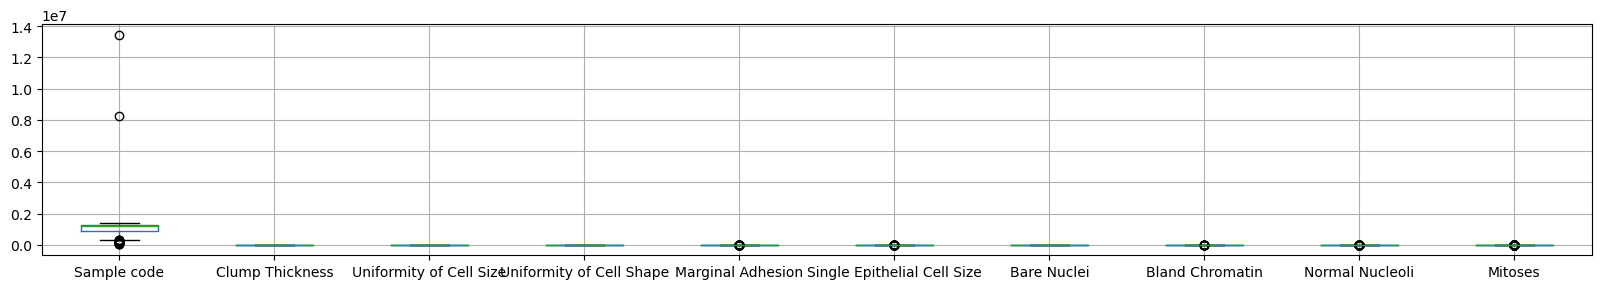

In [ ]:
from matplotlib import pyplot as plt

data2 = data.drop(['Class'],axis=1)
data2['Bare Nuclei'] = pd.to_numeric(data2['Bare Nuclei'])
data2.boxplot(figsize=(20,3))
Z = (data2-data2.mean())/data2.std()
Z[20:25]
print('总行数 %d' % (Z.shape[0]))
Z2 = Z.loc[((Z > -3).sum(axis=1)==9) & ((Z <= 3).sum(axis=1)==9),:]
print('含有数据异常点总行数 %d' % (Z2.shape[0]))


In [ ]:
dups = data.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
data.loc[[11,28]]

print('Number of rows before discarding duplicates = %d' % (data.shape[0]))
data2 = data.drop_duplicates()
print('Number of rows after discarding duplicates = %d' % (data2.shape[0]))

Number of duplicate rows = 8
Number of rows before discarding duplicates = 699
Number of rows after discarding duplicates = 691


In [ ]:
daily=pd.read_csv('./DTW_prec.csv', header='infer')
daily.index = pd.to_datetime(daily['DATE'])
daily = daily['PRCP']
ax = daily.plot(kind='line',figsize=(15,3))
ax.set_title('Daily Precipitation (variance = %.4f)' % (daily.var()))
monthly = daily.groupby(pd.Grouper(freq='M')).sum()
ax = monthly.plot(kind='line',figsize=(15,3))
ax.set_title('Monthly Precipitation (variance = %.4f)' % (monthly.var()))
annual = daily.groupby(pd.Grouper(freq='Y')).sum()
ax = annual.plot(kind='line',figsize=(15,3))
ax.set_title('Annual Precipitation (variance = %.4f)' % (annual.var()))

Text(0.5, 1.0, 'Annual Precipitation (variance = 23.6997)')

In [ ]:
data.head()
sample = data.sample(n=3)
sample
sample = data.sample(frac=0.01, random_state=1)
sample
sample = data.sample(frac=0.01, replace=True, random_state=1)
sample


,Sample code,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
37,1081791,6,2,1,1,1,1,7,1,1,2
235,1241232,3,1,4,1,2,NaN,3,1,1,2
72,1124651,1,3,3,2,2,1,7,2,1,2
645,1303489,3,1,1,1,2,1,2,1,1,2
144,1184241,2,1,1,1,2,1,2,1,1,2
129,1177512,1,1,1,1,10,1,1,1,1,2
583,1115762,3,1,1,1,2,1,1,1,1,2


In [ ]:
data['Clump Thickness'].hist(bins=10)
data['Clump Thickness'].value_counts(sort=False)
bins = pd.cut(data['Clump Thickness'],4)
bins.value_counts(sort=False)
bins = pd.qcut(data['Clump Thickness'],4)
bins.value_counts(sort=False)

(0.999, 2.0]    195
(2.0, 4.0]      188
(4.0, 6.0]      164
(6.0, 10.0]     152
Name: Clump Thickness, dtype: int64

[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


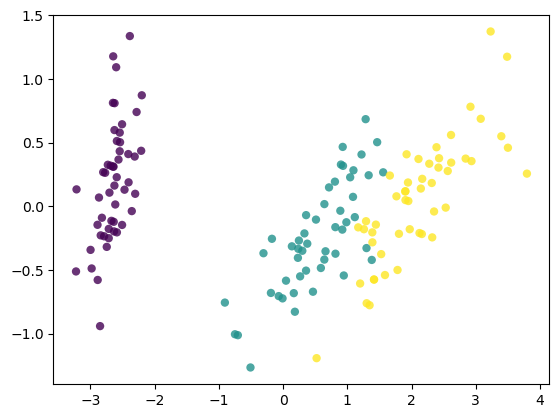

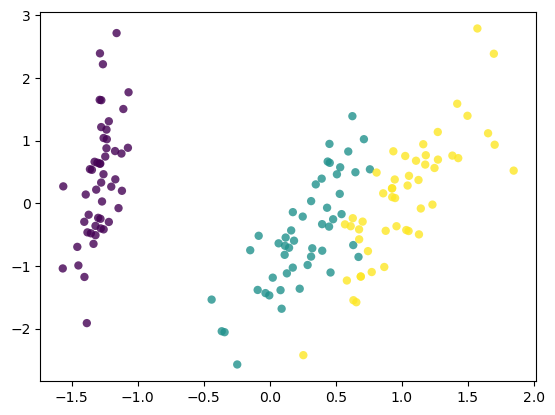

0.9776852063187949
(150, 2)


In [ ]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
iris = datasets.load_iris()    #从sklearn包中获取iris数据
cov_data = np.corrcoef(iris.data.T)
print(cov_data)
print (iris.feature_names)
from sklearn.decomposition import PCA
pca_2c = PCA(n_components=2)
X_pca_2c = pca_2c.fit_transform(iris.data)
X_pca_2c.shape
plt.scatter(X_pca_2c[:,0], X_pca_2c[:,1], c=iris.target, alpha=0.8, edgecolors='none')
plt.show()
pca_2c.explained_variance_ratio_.sum()
pca_2c.components_
pca_2cw = PCA(n_components=2, whiten=True)
X_pca_1cw = pca_2cw.fit_transform(iris.data)
plt.scatter(X_pca_1cw[:,0], X_pca_1cw[:,1], c=iris.target, alpha=0.8, edgecolors='none')
plt.show()
pca_2cw.explained_variance_ratio_.sum()
pca_95pc = PCA(n_components=0.95)
X_pca_95pc = pca_95pc.fit_transform(iris.data)
print (pca_95pc.explained_variance_ratio_.sum())
print (X_pca_95pc.shape)

In [ ]:
import pandas as pd


salary=pd.read_csv('salary_r.csv')
salary=salary.dropna(axis=0)
salary.head()
from patsy.contrasts import Treatment
contrast=Treatment(reference=3).code_without_intercept([1,2,3])
print (contrast)

ContrastMatrix(array([[1., 0.],
                      [0., 1.],
                      [0., 0.]]),
               ['[T.1]', '[T.2]'])
